# Simple Architecture: Training

Clean training uses 16-bit messages and the project implementation. The full-dataset target is validation BER < 0.2 with PSNR >= 30 dB. The test split remains unused.

## Setup

Relative paths assume execution from the notebooks directory. Each experiment writes to a separate log and checkpoint folder.

In [ ]:
import os
import sys

sys.path.append("..")

from src.utils import SEED, set_seed
import torch
from torch.utils.data import DataLoader, Subset
from src.data import WatermarkDataset
from src.train import TrainConfig, build_models, fit

set_seed()

data_dir = "../data"
splits_file = "../data/splits.json"
results_dir = "../results/simple-clean-16bit-v1"

tiny_config = TrainConfig(
    architecture="simple",
    simple_version="legacy",
    experiment_name="tiny",
    message_length=16,
    epochs=200,
    batch_size=8,
    learning_rate=1e-3,
    image_loss_weight=0.0,
    encoder_max_delta=0.03,
    checkpoint_metric="ber",
    print_every=20,
    checkpoint_dir=results_dir + "/checkpoints",
    log_path=results_dir + "/tiny.csv",
)

## Tiny Subset

The first eight training images receive fixed 16-bit messages. Shuffling is disabled to preserve these pairs; the existing split is not modified.

In [2]:
dataset = WatermarkDataset(data_dir, splits_file, split="train")
tiny_dataset = Subset(dataset, range(8))

tiny_loader = DataLoader(
    tiny_dataset,
    batch_size=8,
    shuffle=False,
)

generator = torch.Generator()
generator.manual_seed(SEED)

tiny_messages = torch.randint(
    low=0,
    high=2,
    size=(8, 16),
    generator=generator,
    dtype=torch.float32,
)

images, masks = next(iter(tiny_loader))
print("Images:", images.shape)
print("Masks:", masks.shape)
print("Messages:", tiny_messages.shape)

Images: torch.Size([8, 3, 128, 128])
Masks: torch.Size([8, 1, 128, 128])
Messages: torch.Size([8, 16])


## Model and Objective

The encoder concatenates RGB and spatially expanded message bits, then uses three Conv-ReLU blocks with channels (64, 64, 32) and a final convolution to predict a residual. Content masking preserves padding: `watermarked = clamp(image + residual * mask, 0, 1)`. The decoder uses three Conv-ReLU-MaxPool blocks with channels (32, 64, 128), global average pooling and a linear output. Neither model uses BatchNorm; the decoder does not use the mask.

These are the original encoder and decoder operations, with the project's later content-mask support retained. The full-dataset runs use 16-bit messages and no residual bound. 

The full-training objective is `loss = message BCE + image_loss_weight * image MSE`. BCE is computed from decoder logits; image MSE is computed over content pixels before any attack. Image-loss weighting penalizes average distortion but does not impose a maximum pixel change. PSNR also excludes padding. BER measures incorrect bits, while exact accuracy requires all 16 bits to be correct.

In [3]:
encoder, decoder = build_models(tiny_config)

encoder_parameters = 0
for parameter in encoder.parameters():
    encoder_parameters += parameter.numel()

decoder_parameters = 0
for parameter in decoder.parameters():
    decoder_parameters += parameter.numel()

print("Encoder parameters:", encoder_parameters)
print("Decoder parameters:", decoder_parameters)
print("Total parameters:", encoder_parameters + decoder_parameters)

Encoder parameters: 67267
Decoder parameters: 95312
Total parameters: 162579


### Forward Check

The output retains the image shape and range [0, 1], with 16 decoder logits per image. The tiny configuration limits pixel changes to 0.03 and leaves padding unchanged.

In [4]:
encoder.eval()
decoder.eval()

with torch.no_grad():
    watermarked = encoder(images, tiny_messages, masks)
    logits = decoder(watermarked, masks)

difference = (watermarked - images).abs()
padding = masks.expand_as(images) == 0
padding_unchanged = torch.equal(watermarked[padding], images[padding])

print("Watermarked images:", watermarked.shape)
print("Decoder logits:", logits.shape)
print("Minimum pixel value:", watermarked.min().item())
print("Maximum pixel value:", watermarked.max().item())
print("Largest pixel change:", difference.max().item())
print("Padding unchanged:", padding_unchanged)

Watermarked images: torch.Size([8, 3, 128, 128])
Decoder logits: torch.Size([8, 16])
Minimum pixel value: 0.0
Maximum pixel value: 0.998410165309906
Largest pixel change: 0.0034843385219573975
Padding unchanged: True


## Tiny-Set Training

Train for 200 epochs using Adam, message BCE only and a residual bound of 0.03. The same images and messages are used in both passes: `val` metrics here check memorization in evaluation mode, not generalization. Full-dataset training requires BER 0 and exact accuracy 1 on this check.

In [5]:
checkpoint_dir = tiny_config.checkpoint_dir + "/" + tiny_config.experiment_name

if os.path.exists(tiny_config.log_path) or os.path.exists(checkpoint_dir):
    raise FileExistsError("Results already exist. Choose a different results_dir.")

tiny_encoder, tiny_decoder, tiny_history = fit(
    train_loader=tiny_loader,
    val_loader=tiny_loader,
    config=tiny_config,
    fixed_train_messages=tiny_messages,
    fixed_val_messages=tiny_messages,
)

Epoch 1/200 | train_loss=0.6891 | train_BER=0.4609 | train_exact=0.0000 | 8.9s
Epoch 20/200 | train_loss=0.5976 | train_BER=0.3281 | train_exact=0.0000 | 0.2s
Epoch 40/200 | train_loss=0.4143 | train_BER=0.2188 | train_exact=0.1250 | 0.2s
Epoch 60/200 | train_loss=0.3561 | train_BER=0.2031 | train_exact=0.1250 | 0.1s
Epoch 80/200 | train_loss=0.2719 | train_BER=0.1250 | train_exact=0.1250 | 0.2s
Epoch 100/200 | train_loss=0.1694 | train_BER=0.0312 | train_exact=0.7500 | 0.2s
Epoch 120/200 | train_loss=0.0942 | train_BER=0.0000 | train_exact=1.0000 | 0.2s
Epoch 140/200 | train_loss=0.0497 | train_BER=0.0000 | train_exact=1.0000 | 0.2s
Epoch 160/200 | train_loss=0.0261 | train_BER=0.0000 | train_exact=1.0000 | 0.2s
Epoch 180/200 | train_loss=0.0144 | train_BER=0.0000 | train_exact=1.0000 | 0.2s
Epoch 200/200 | train_loss=0.0086 | train_BER=0.0000 | train_exact=1.0000 | 0.2s
Training time: 0.8 minutes


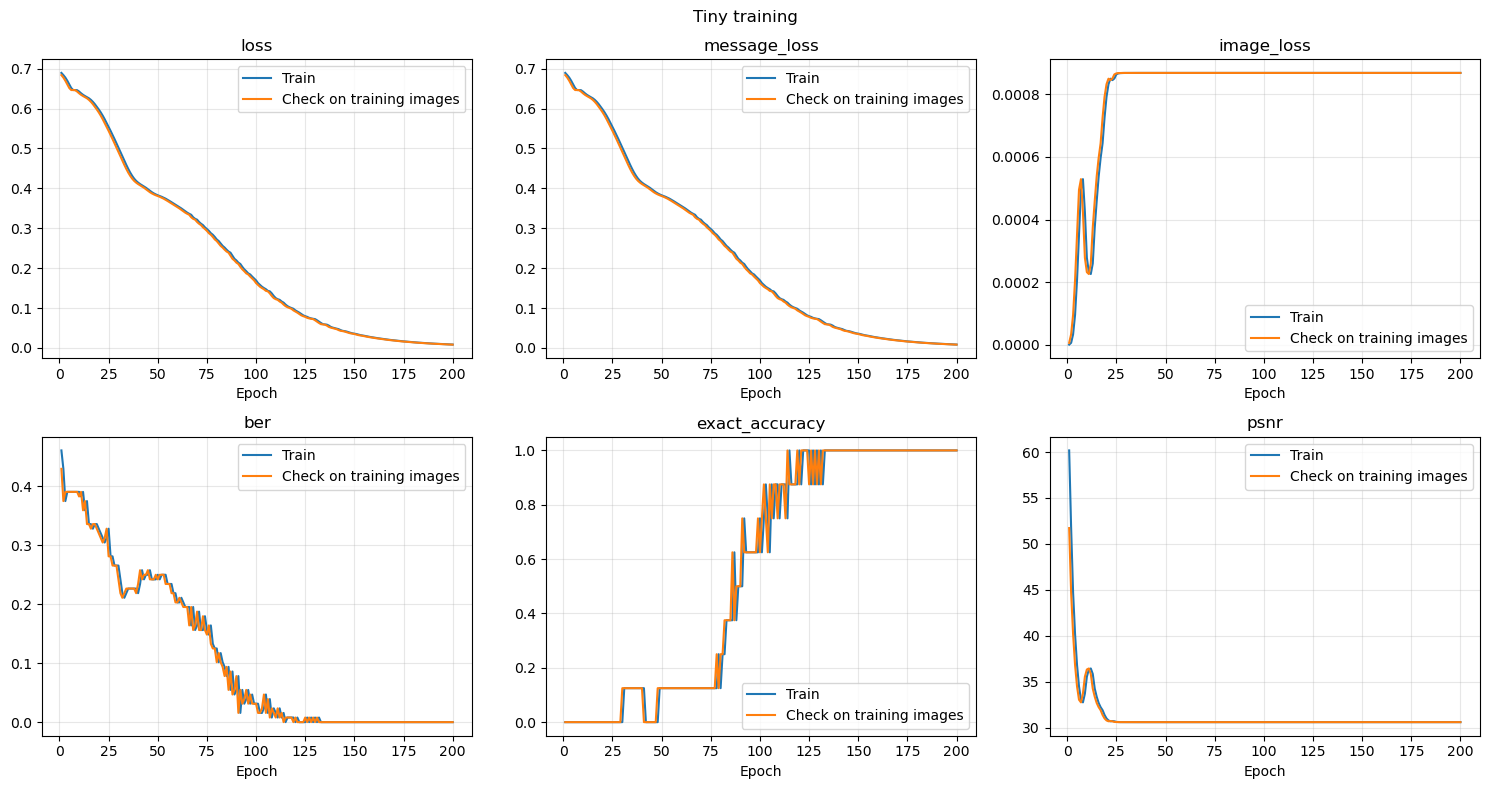

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

tiny_results = pd.read_csv(tiny_config.log_path)
metrics = ["loss", "message_loss", "image_loss", "ber", "exact_accuracy", "psnr"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for axis, metric in zip(axes.flat, metrics):
    axis.plot(tiny_results["epoch"], tiny_results["train_" + metric], label="Train")
    axis.plot(tiny_results["epoch"], tiny_results["val_" + metric], label="Check on training images")
    axis.set_title(metric)
    axis.set_xlabel("Epoch")
    axis.legend()
    axis.grid(alpha=0.3)

fig.suptitle("Tiny training")
fig.tight_layout()
plt.show()

### Tiny-Set Result

The bounded tiny run completed 200 epochs in approximately 0.8 minutes. Its final evaluation-mode BER was **0**, exact message accuracy **1**, and content PSNR **30.62 dB**. This confirms memorization of eight fixed image-message pairs by that variant, not generalization or an unbounded-model overfitting result.

## Full-Dataset Message-Only Training

A new unbounded simple model is trained from scratch on 4,000 training images, with 500 separate validation images. Images are resized and padded to 128x128. Fresh random training messages are generated each batch; validation messages remain fixed with seed 95. All full runs use Adam with learning rate 0.001, batch size 32 and 16-bit messages.

Image-loss weight is zero and there is no residual bound, so this diagnostic tests message recovery without a penalty on image distortion. The best checkpoint is selected by minimum validation loss within the run. No attacks or test images are used.

In [6]:
train_loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    drop_last=True,
    num_workers=4,
)
val_dataset = WatermarkDataset(data_dir, splits_file, split="val")
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

validation_generator = torch.Generator()
validation_generator.manual_seed(SEED)
validation_messages = torch.randint(
    low=0,
    high=2,
    size=(len(val_dataset), 16),
    generator=validation_generator,
    dtype=torch.float32,
)

message_config = TrainConfig(
    architecture="simple",
    experiment_name="message-only",
    message_length=16,
    epochs=20,
    batch_size=32,
    learning_rate=1e-3,
    image_loss_weight=0.0,
    encoder_max_delta=None,
    attack_configs=None,
    validation_attack_configs=None,
    checkpoint_metric="loss",
    print_every=1,
    checkpoint_dir=results_dir + "/checkpoints",
    log_path=results_dir + "/message-only.csv",
)
print("Training images:", len(dataset))
print("Validation images:", len(val_dataset))

Training images: 4000
Validation images: 500


In [7]:
if tiny_history[-1]["val_ber"] != 0 or tiny_history[-1]["val_exact_accuracy"] != 1:
    raise RuntimeError("The tiny memorization check must pass before full training.")

checkpoint_dir = message_config.checkpoint_dir + "/" + message_config.experiment_name
if os.path.exists(message_config.log_path) or os.path.exists(checkpoint_dir):
    raise FileExistsError("Results already exist. Choose a different experiment path.")

message_encoder, message_decoder, message_history = fit(
    train_loader=train_loader,
    val_loader=val_loader,
    config=message_config,
    fixed_val_messages=validation_messages,
)

Epoch 1/20 | train_loss=0.6484 | train_BER=0.4219 | train_exact=0.0000 | val_loss=0.6149 | val_BER=0.3976 | val_exact=0.0000 | val_PSNR=7.50 | 41.0s
Epoch 2/20 | train_loss=0.5947 | train_BER=0.3800 | train_exact=0.0008 | val_loss=0.5743 | val_BER=0.3761 | val_exact=0.0000 | val_PSNR=8.23 | 37.9s
Epoch 3/20 | train_loss=0.5598 | train_BER=0.3659 | train_exact=0.0003 | val_loss=0.5429 | val_BER=0.3485 | val_exact=0.0000 | val_PSNR=7.74 | 39.3s
Epoch 4/20 | train_loss=0.5380 | train_BER=0.3503 | train_exact=0.0003 | val_loss=0.5261 | val_BER=0.3400 | val_exact=0.0000 | val_PSNR=7.00 | 47.3s
Epoch 5/20 | train_loss=0.5251 | train_BER=0.3383 | train_exact=0.0008 | val_loss=0.5117 | val_BER=0.3261 | val_exact=0.0020 | val_PSNR=7.48 | 47.0s
Epoch 6/20 | train_loss=0.5181 | train_BER=0.3315 | train_exact=0.0005 | val_loss=0.5071 | val_BER=0.3191 | val_exact=0.0020 | val_PSNR=7.86 | 42.3s
Epoch 7/20 | train_loss=0.5039 | train_BER=0.3140 | train_exact=0.0003 | val_loss=0.4949 | val_BER=0.3040 

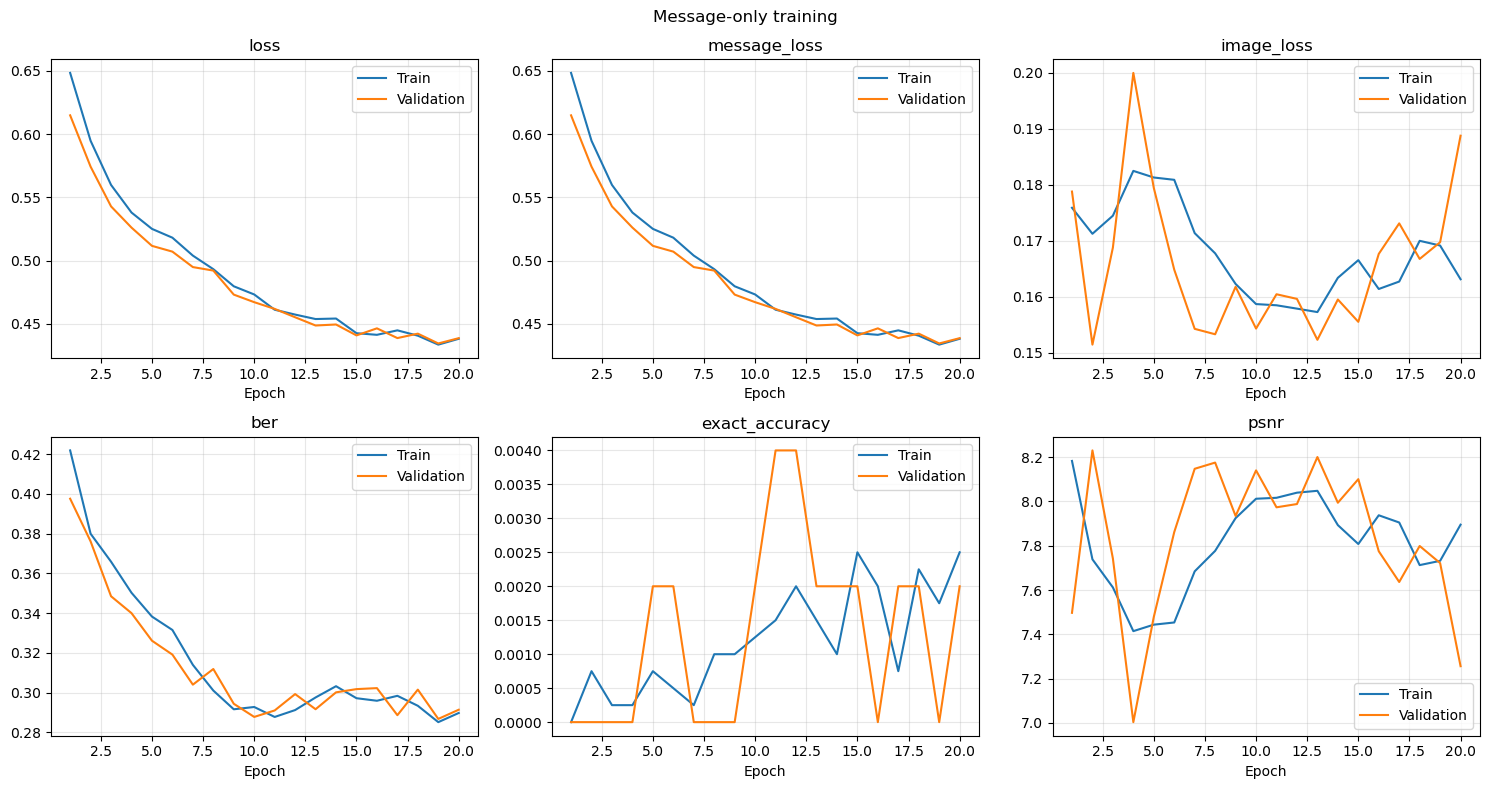

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

message_results = pd.read_csv(message_config.log_path)
metrics = ["loss", "message_loss", "image_loss", "ber", "exact_accuracy", "psnr"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for axis, metric in zip(axes.flat, metrics):
    axis.plot(message_results["epoch"], message_results["train_" + metric], label="Train")
    axis.plot(message_results["epoch"], message_results["val_" + metric], label="Validation")
    axis.set_title(metric)
    axis.set_xlabel("Epoch")
    axis.legend()
    axis.grid(alpha=0.3)

fig.suptitle("Message-only training")
fig.tight_layout()
plt.show()

### Message-Only Results

Validation BCE decreased from 0.6149 to 0.4386 over 20 epochs, and validation BER decreased from approximately 0.398 to 0.291. Training and validation curves remain close, without a clear generalization gap. This improvement shows that the model is learning to recover message bits, although BER mostly fluctuates around 0.29-0.30 in the second half of the run.

The checkpoint selected by minimum validation loss is epoch 19: BER 0.2868, exact message accuracy 0, and PSNR 7.72 dB. At epoch 20, BER is 0.2914 and exact accuracy is 0.002 (one of 500 messages). Message recovery is improving overall, but the very low PSNR indicates large differences between the original and encoded images. Neither checkpoint meets the joint target of BER < 0.2 and PSNR >= 30 dB.

With `image_loss_weight=0`, the training objective rewards message recovery without penalizing changes to the image. We therefore introduce a positive image-loss weight to penalize image MSE and encourage the encoder to preserve the original image while embedding the message. The aim is an encoded image with acceptable quality, not just a lower message loss.

The falling BER makes this a reasonable next experiment: the model has learned some message information, and we now test whether that ability can be retained while reducing image distortion. We first test weights 0.03 and 0.3, then stronger penalties of 0.8 and 1.0. Each run starts from fresh weights with the same seed, data and initial 20-epoch budget. The results must be judged by BER and PSNR together; an image-loss penalty does not guarantee that either target will be reached.

## Image-Loss Weight 0.03

This run adds a small image-quality penalty: `loss = message BCE + 0.03 * image MSE`. The architecture, split, validation messages, learning rate and 20-epoch budget remain unchanged. Training starts from new weights with the same seed, not from the message-only checkpoint. There are no attacks or residual bound. The comparison tests whether PSNR improves while retaining message recovery.

In [12]:
weight_config = TrainConfig(
    architecture="simple",
    experiment_name="weight-0.03",
    message_length=16,
    epochs=20,
    batch_size=32,
    learning_rate=1e-3,
    image_loss_weight=0.03,
    encoder_max_delta=None,
    attack_configs=None,
    validation_attack_configs=None,
    checkpoint_metric="loss",
    print_every=1,
    checkpoint_dir=results_dir + "/checkpoints",
    log_path=results_dir + "/weight-0.03.csv",
)

In [13]:
checkpoint_dir = weight_config.checkpoint_dir + "/" + weight_config.experiment_name
if os.path.exists(weight_config.log_path) or os.path.exists(checkpoint_dir):
    raise FileExistsError("Results already exist. Choose a different experiment path.")

weight_encoder, weight_decoder, weight_history = fit(
    train_loader=train_loader,
    val_loader=val_loader,
    config=weight_config,
    fixed_val_messages=validation_messages,
)

Epoch 1/20 | train_loss=0.6688 | train_BER=0.4515 | train_exact=0.0000 | val_loss=0.6490 | val_BER=0.4414 | val_exact=0.0000 | val_PSNR=9.36 | 40.4s
Epoch 2/20 | train_loss=0.6162 | train_BER=0.4109 | train_exact=0.0000 | val_loss=0.5936 | val_BER=0.3989 | val_exact=0.0000 | val_PSNR=9.89 | 47.1s
Epoch 3/20 | train_loss=0.5776 | train_BER=0.3746 | train_exact=0.0005 | val_loss=0.5685 | val_BER=0.3771 | val_exact=0.0000 | val_PSNR=9.36 | 48.6s
Epoch 4/20 | train_loss=0.5551 | train_BER=0.3603 | train_exact=0.0005 | val_loss=0.5506 | val_BER=0.3630 | val_exact=0.0000 | val_PSNR=9.54 | 46.8s
Epoch 5/20 | train_loss=0.5348 | train_BER=0.3525 | train_exact=0.0010 | val_loss=0.5237 | val_BER=0.3525 | val_exact=0.0000 | val_PSNR=8.97 | 41.9s
Epoch 6/20 | train_loss=0.5230 | train_BER=0.3564 | train_exact=0.0000 | val_loss=0.5150 | val_BER=0.3439 | val_exact=0.0000 | val_PSNR=8.67 | 38.6s
Epoch 7/20 | train_loss=0.5123 | train_BER=0.3484 | train_exact=0.0003 | val_loss=0.5063 | val_BER=0.3468 

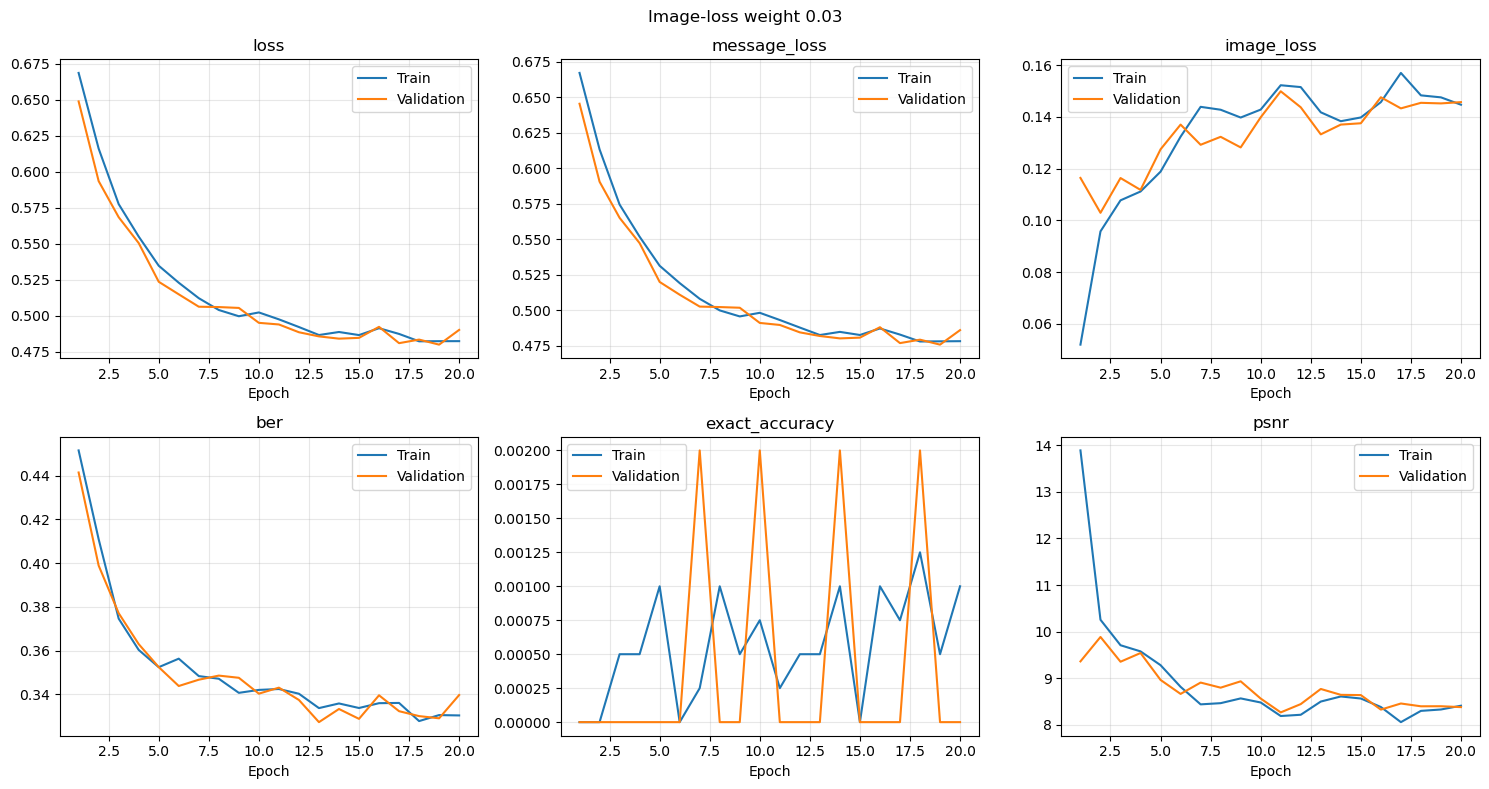

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

weight_results = pd.read_csv(weight_config.log_path)
metrics = ["loss", "message_loss", "image_loss", "ber", "exact_accuracy", "psnr"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for axis, metric in zip(axes.flat, metrics):
    axis.plot(weight_results["epoch"], weight_results["train_" + metric], label="Train")
    axis.plot(weight_results["epoch"], weight_results["val_" + metric], label="Validation")
    axis.set_title(metric)
    axis.set_xlabel("Epoch")
    axis.legend()
    axis.grid(alpha=0.3)

fig.suptitle("Image-loss weight 0.03")
fig.tight_layout()
plt.show()

### Weight 0.03 Results

The checkpoint with minimum validation loss is epoch 19: BER 0.3291, exact message accuracy 0 and PSNR 8.40 dB. Compared with message-only training, image quality improves slightly while message recovery worsens. Neither run meets the joint BER and PSNR target.

## Image-Loss Weight 0.3

The next run increases the image-loss weight to 0.3. The model starts from fresh weights with the same seed, architecture, data loaders, validation messages and 20-epoch budget. No attacks or residual bound are used. Only the loss weight changes.

In [16]:
strong_weight_config = TrainConfig(
    architecture="simple",
    experiment_name="weight-0.3",
    message_length=16,
    epochs=20,
    batch_size=32,
    learning_rate=1e-3,
    image_loss_weight=0.3,
    encoder_max_delta=None,
    attack_configs=None,
    validation_attack_configs=None,
    checkpoint_metric="loss",
    print_every=1,
    checkpoint_dir=results_dir + "/checkpoints",
    log_path=results_dir + "/weight-0.3.csv",
)

In [17]:
checkpoint_dir = strong_weight_config.checkpoint_dir + "/" + strong_weight_config.experiment_name
if os.path.exists(strong_weight_config.log_path) or os.path.exists(checkpoint_dir):
    raise FileExistsError("Results already exist. Choose a different experiment path.")

strong_weight_encoder, strong_weight_decoder, strong_weight_history = fit(
    train_loader=train_loader,
    val_loader=val_loader,
    config=strong_weight_config,
    fixed_val_messages=validation_messages,
)

Epoch 1/20 | train_loss=0.6935 | train_BER=0.5008 | train_exact=0.0000 | val_loss=0.6935 | val_BER=0.5043 | val_exact=0.0000 | val_PSNR=32.75 | 41.1s
Epoch 2/20 | train_loss=0.6726 | train_BER=0.4380 | train_exact=0.0000 | val_loss=0.6630 | val_BER=0.4355 | val_exact=0.0000 | val_PSNR=22.14 | 41.1s
Epoch 3/20 | train_loss=0.6497 | train_BER=0.4339 | train_exact=0.0000 | val_loss=0.6387 | val_BER=0.4185 | val_exact=0.0000 | val_PSNR=18.19 | 45.5s
Epoch 4/20 | train_loss=0.6286 | train_BER=0.4113 | train_exact=0.0003 | val_loss=0.6237 | val_BER=0.4138 | val_exact=0.0000 | val_PSNR=17.87 | 45.9s
Epoch 5/20 | train_loss=0.6156 | train_BER=0.4053 | train_exact=0.0003 | val_loss=0.6058 | val_BER=0.3914 | val_exact=0.0000 | val_PSNR=17.02 | 43.4s
Epoch 6/20 | train_loss=0.6037 | train_BER=0.3939 | train_exact=0.0000 | val_loss=0.5980 | val_BER=0.3969 | val_exact=0.0000 | val_PSNR=16.79 | 43.3s
Epoch 7/20 | train_loss=0.5933 | train_BER=0.3989 | train_exact=0.0000 | val_loss=0.5910 | val_BER=0

## Continue Weight 0.3 to Epoch 40

Validation loss was still decreasing at epoch 20, so the same experiment is continued to a total of 40 epochs. The last checkpoint restores model weights, Adam state and random-number-generator states. Data loaders, fixed validation messages, learning rate, batch size and loss weight remain unchanged. The encoder retains content masking and has no residual bound.

In [18]:
import importlib
import pandas as pd
import src.simple_encoder as simple_encoder_module
import src.simple_decoder as simple_decoder_module
import src.train as train_module

importlib.reload(simple_encoder_module)
importlib.reload(simple_decoder_module)
importlib.reload(train_module)
from src.train import TrainConfig, fit

continue_checkpoint = results_dir + "/checkpoints/weight-0.3/last.pt"
continue_state = torch.load(continue_checkpoint, map_location="cpu", weights_only=False)
continue_config = TrainConfig(**continue_state["config"])
continue_config.epochs = 40
continue_config.print_every = 1

completed_epochs = continue_state["epoch"] + 1
continued_log = pd.read_csv(continue_config.log_path)
if int(continued_log.iloc[-1]["epoch"]) != completed_epochs:
    raise ValueError("Checkpoint and log do not end at the same epoch.")

print("Checkpoint:", continue_checkpoint)
print("Completed epochs:", completed_epochs)
print("Target epochs:", continue_config.epochs)
print("Image-loss weight:", continue_config.image_loss_weight)
print("Residual bound:", continue_config.encoder_max_delta)

Checkpoint: ../results/simple-clean-16bit-v1/checkpoints/weight-0.3/last.pt
Completed epochs: 20
Target epochs: 40
Image-loss weight: 0.3
Residual bound: None


In [19]:
continued_encoder, continued_decoder, continued_history = fit(
    train_loader=train_loader,
    val_loader=val_loader,
    config=continue_config,
    resume_from=continue_checkpoint,
    fixed_val_messages=validation_messages,
)

Epoch 21/40 | train_loss=0.5429 | train_BER=0.3694 | train_exact=0.0000 | val_loss=0.5415 | val_BER=0.3549 | val_exact=0.0000 | val_PSNR=17.39 | 45.7s
Epoch 22/40 | train_loss=0.5410 | train_BER=0.3601 | train_exact=0.0000 | val_loss=0.5412 | val_BER=0.3591 | val_exact=0.0000 | val_PSNR=15.87 | 48.7s
Epoch 23/40 | train_loss=0.5358 | train_BER=0.3582 | train_exact=0.0008 | val_loss=0.5296 | val_BER=0.3461 | val_exact=0.0000 | val_PSNR=16.62 | 48.7s
Epoch 24/40 | train_loss=0.5302 | train_BER=0.3480 | train_exact=0.0005 | val_loss=0.5320 | val_BER=0.3510 | val_exact=0.0000 | val_PSNR=17.55 | 49.9s
Epoch 25/40 | train_loss=0.5335 | train_BER=0.3495 | train_exact=0.0000 | val_loss=0.5290 | val_BER=0.3504 | val_exact=0.0000 | val_PSNR=16.63 | 48.9s
Epoch 26/40 | train_loss=0.5289 | train_BER=0.3494 | train_exact=0.0003 | val_loss=0.5299 | val_BER=0.3461 | val_exact=0.0000 | val_PSNR=16.56 | 51.0s
Epoch 27/40 | train_loss=0.5298 | train_BER=0.3488 | train_exact=0.0008 | val_loss=0.5265 | va

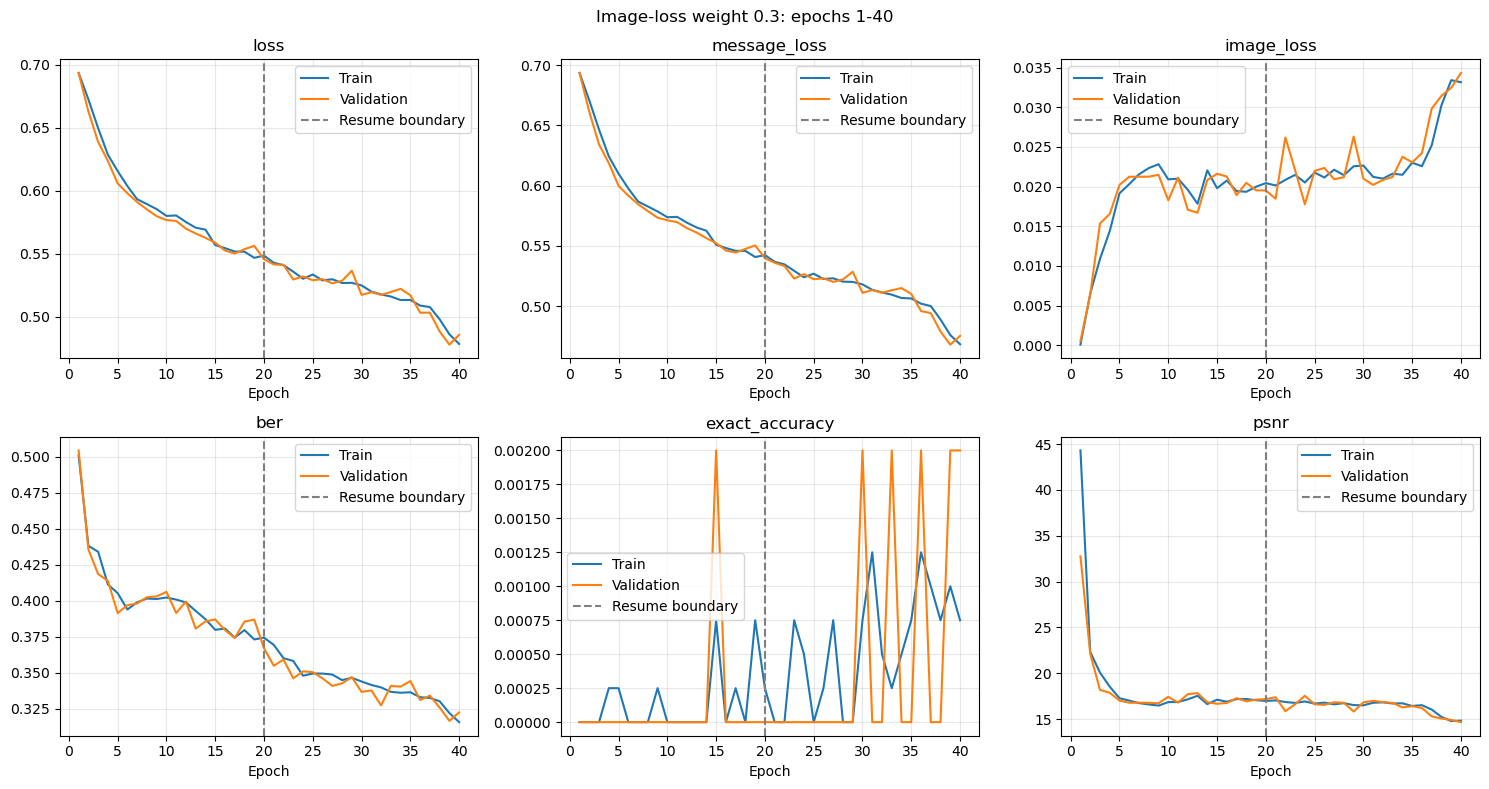

In [20]:
import matplotlib.pyplot as plt

continued_results = pd.read_csv(continue_config.log_path)
metrics = ["loss", "message_loss", "image_loss", "ber", "exact_accuracy", "psnr"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for axis, metric in zip(axes.flat, metrics):
    axis.plot(continued_results["epoch"], continued_results["train_" + metric], label="Train")
    axis.plot(continued_results["epoch"], continued_results["val_" + metric], label="Validation")
    axis.axvline(20, color="gray", linestyle="--", label="Resume boundary")
    axis.set_title(metric)
    axis.set_xlabel("Epoch")
    axis.legend()
    axis.grid(alpha=0.3)

fig.suptitle("Image-loss weight 0.3: epochs 1-40")
fig.tight_layout()
plt.show()

### Weight 0.3 Results After 40 Epochs

Validation BER continued to improve overall during the additional training: it decreased from 0.3670 at epoch 20 to 0.3225 at epoch 40. Improvement was still visible near the end, with BER reaching 0.3166 at epoch 39 before a small increase in the final epoch. The model was therefore still learning, rather than showing a clear plateau.

However, PSNR decreased at the same time: from 17.19 dB at epoch 20 to 14.92 dB at epoch 39 and 14.67 dB at epoch 40. Better message recovery came with larger differences between the original and encoded images. Image quality remained far below the required 30 dB, and BER was also above the 0.2 target.

We stop this run at 40 epochs because the improving BER does not compensate for the worsening and already unacceptable image quality.

## Image-Loss Weight 0.8

After the previous experiments, this run tests a stronger image-quality penalty: `loss = message BCE + 0.8 * image MSE`. It starts from fresh weights for 20 epochs on the same 4,000 training images, with the same seed, batch size 32, learning rate 0.001 and fixed validation messages.

The comparison uses the first 20 epochs of the other runs. A larger penalty may improve PSNR at the expense of BER; neither outcome is assumed in advance.

In [23]:
from src.train import TrainConfig, fit

higher_weight_config = TrainConfig(
    architecture="simple",
    simple_version="original",
    experiment_name="weight-0.8",
    message_length=16,
    epochs=20,
    batch_size=32,
    learning_rate=1e-3,
    image_loss_weight=0.8,
    encoder_max_delta=None,
    attack_configs=None,
    validation_attack_configs=None,
    checkpoint_metric="loss",
    print_every=1,
    checkpoint_dir=results_dir + "/checkpoints",
    log_path=results_dir + "/weight-0.8.csv",
)

print("Training images:", len(train_loader.dataset))
print("Validation images:", len(val_loader.dataset))
print("Epochs:", higher_weight_config.epochs)
print("Image-loss weight:", higher_weight_config.image_loss_weight)

Training images: 4000
Validation images: 500
Epochs: 20
Image-loss weight: 0.8


In [24]:
checkpoint_dir = higher_weight_config.checkpoint_dir + "/" + higher_weight_config.experiment_name
if os.path.exists(higher_weight_config.log_path) or os.path.exists(checkpoint_dir):
    raise FileExistsError("Results already exist. Choose a different experiment path.")

higher_weight_encoder, higher_weight_decoder, higher_weight_history = fit(
    train_loader=train_loader,
    val_loader=val_loader,
    config=higher_weight_config,
    fixed_val_messages=validation_messages,
)

Epoch 1/20 | train_loss=0.6935 | train_BER=0.5011 | train_exact=0.0000 | val_loss=0.6936 | val_BER=0.5060 | val_exact=0.0000 | val_PSNR=48.28 | 42.6s
Epoch 2/20 | train_loss=0.6869 | train_BER=0.4746 | train_exact=0.0000 | val_loss=0.6686 | val_BER=0.4336 | val_exact=0.0000 | val_PSNR=24.93 | 42.3s
Epoch 3/20 | train_loss=0.6647 | train_BER=0.4373 | train_exact=0.0000 | val_loss=0.6583 | val_BER=0.4440 | val_exact=0.0000 | val_PSNR=24.02 | 43.0s
Epoch 4/20 | train_loss=0.6452 | train_BER=0.4266 | train_exact=0.0000 | val_loss=0.6383 | val_BER=0.4124 | val_exact=0.0000 | val_PSNR=20.86 | 42.1s
Epoch 5/20 | train_loss=0.6338 | train_BER=0.4159 | train_exact=0.0003 | val_loss=0.6262 | val_BER=0.4144 | val_exact=0.0000 | val_PSNR=21.29 | 42.0s
Epoch 6/20 | train_loss=0.6261 | train_BER=0.4229 | train_exact=0.0000 | val_loss=0.6231 | val_BER=0.4243 | val_exact=0.0000 | val_PSNR=20.84 | 43.5s
Epoch 7/20 | train_loss=0.6199 | train_BER=0.4226 | train_exact=0.0000 | val_loss=0.6169 | val_BER=0

### Weight 0.8 Results

The checkpoint selected by minimum validation loss is epoch 20: BER 0.3969, exact message accuracy 0 and PSNR 21.33 dB. Message loss decreased overall, but validation BER fluctuated in the later epochs rather than showing steady improvement.

PSNR around 21 dB is a substantial improvement over the selected checkpoints from the lower-weight experiments. The stronger image-loss penalty reduced image distortion, but the encoded images still fall short of the 30 dB quality target, and BER remains above 0.2. The run therefore does not yet provide an acceptable combination of image quality and message recovery.

This improvement in PSNR motivates testing image_loss_weight=1.0 next: we increase the penalty on image changes to see whether image quality can improve further while retaining message recovery.

## Image-Loss Weight 1.0

We now test `image_loss_weight=1.0`, hoping to maintain high PSNR as the model learns to recover the embedded messages.

In [25]:
from src.train import TrainConfig, fit

unit_weight_config = TrainConfig(
    architecture="simple",
    simple_version="original",
    experiment_name="weight-1.0",
    message_length=16,
    epochs=20,
    batch_size=32,
    learning_rate=1e-3,
    image_loss_weight=1.0,
    encoder_max_delta=None,
    attack_configs=None,
    validation_attack_configs=None,
    checkpoint_metric="loss",
    print_every=1,
    checkpoint_dir=results_dir + "/checkpoints",
    log_path=results_dir + "/weight-1.0.csv",
)

print("Training images:", len(train_loader.dataset))
print("Validation images:", len(val_loader.dataset))
print("Epochs:", unit_weight_config.epochs)
print("Image-loss weight:", unit_weight_config.image_loss_weight)

Training images: 4000
Validation images: 500
Epochs: 20
Image-loss weight: 1.0


In [26]:
checkpoint_dir = unit_weight_config.checkpoint_dir + "/" + unit_weight_config.experiment_name
if os.path.exists(unit_weight_config.log_path) or os.path.exists(checkpoint_dir):
    raise FileExistsError("Results already exist. Choose a different experiment path.")

unit_weight_encoder, unit_weight_decoder, unit_weight_history = fit(
    train_loader=train_loader,
    val_loader=val_loader,
    config=unit_weight_config,
    fixed_val_messages=validation_messages,
)

Epoch 1/20 | train_loss=0.6935 | train_BER=0.5000 | train_exact=0.0000 | val_loss=0.6935 | val_BER=0.5051 | val_exact=0.0000 | val_PSNR=50.63 | 38.7s
Epoch 2/20 | train_loss=0.6934 | train_BER=0.5034 | train_exact=0.0000 | val_loss=0.6933 | val_BER=0.5013 | val_exact=0.0000 | val_PSNR=51.83 | 36.1s
Epoch 3/20 | train_loss=0.6896 | train_BER=0.4824 | train_exact=0.0000 | val_loss=0.6703 | val_BER=0.4306 | val_exact=0.0000 | val_PSNR=25.84 | 44.2s
Epoch 4/20 | train_loss=0.6616 | train_BER=0.4421 | train_exact=0.0003 | val_loss=0.6504 | val_BER=0.4508 | val_exact=0.0000 | val_PSNR=22.60 | 45.0s
Epoch 5/20 | train_loss=0.6441 | train_BER=0.4206 | train_exact=0.0000 | val_loss=0.6372 | val_BER=0.4174 | val_exact=0.0000 | val_PSNR=23.09 | 40.7s
Epoch 6/20 | train_loss=0.6363 | train_BER=0.4163 | train_exact=0.0000 | val_loss=0.6361 | val_BER=0.4304 | val_exact=0.0000 | val_PSNR=20.88 | 45.6s
Epoch 7/20 | train_loss=0.6322 | train_BER=0.4222 | train_exact=0.0003 | val_loss=0.6293 | val_BER=0

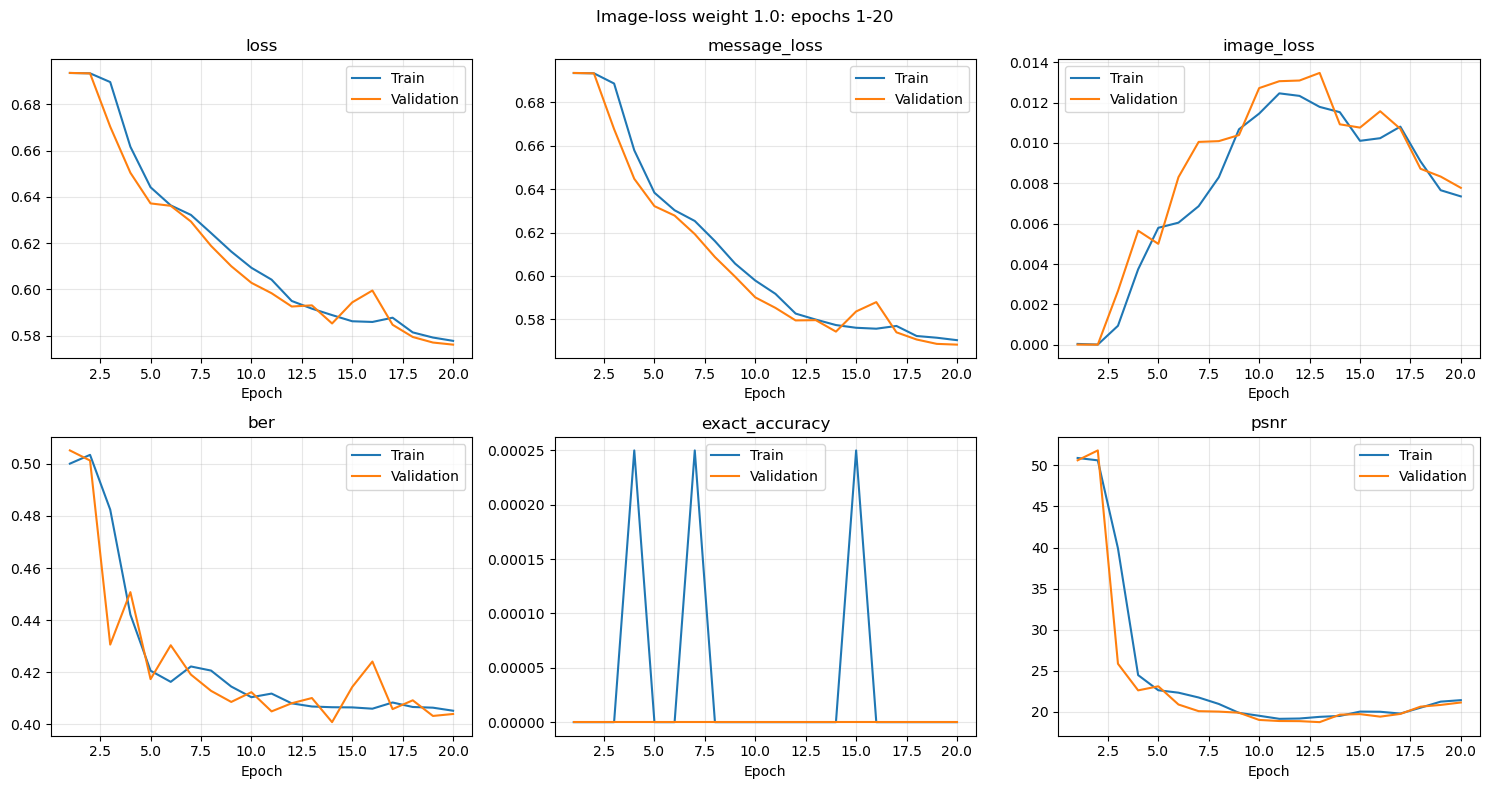

,Epochs,val_loss,val_message_loss,val_ber,val_psnr
0,11-15,0.592759,0.580497,0.4077,19.156935
1,16-20,0.583384,0.573963,0.4093,20.337256


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

unit_results = pd.read_csv(unit_weight_config.log_path)
metrics = ["loss", "message_loss", "image_loss", "ber", "exact_accuracy", "psnr"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for axis, metric in zip(axes.flat, metrics):
    axis.plot(unit_results["epoch"], unit_results["train_" + metric], label="Train")
    axis.plot(unit_results["epoch"], unit_results["val_" + metric], label="Validation")
    axis.set_title(metric)
    axis.set_xlabel("Epoch")
    axis.legend()
    axis.grid(alpha=0.3)
fig.suptitle("Image-loss weight 1.0: epochs 1-20")
fig.tight_layout()
plt.show()

trend_columns = ["val_loss", "val_message_loss", "val_ber", "val_psnr"]
trend_rows = []
for start_epoch, end_epoch in [(11, 15), (16, 20)]:
    window = unit_results[unit_results["epoch"].between(start_epoch, end_epoch)]
    row = {"Epochs": str(start_epoch) + "-" + str(end_epoch)}
    for metric in trend_columns:
        row[metric] = window[metric].mean()
    trend_rows.append(row)
display(pd.DataFrame(trend_rows).round(6))

### Weight 1.0 Result

After 20 epochs with `image_loss_weight=1.0`, PSNR was **21.12 dB**, below the **30 dB** target. Epoch 20 had the lowest validation total loss in this run, but the encoded images still differed too much from the originals under our quality criterion.

At this point, validation BER was **0.4040** and exact message accuracy was **0**, meaning that none of the 500 validation messages was recovered completely. Message BCE was still decreasing, and longer training might also reduce BER further; this run does not establish convergence or rule out further improvement.

Compared with weight 0.8 (PSNR 21.33 dB, BER 0.3969), weight 1.0 did not improve either final-epoch metric in these runs. We therefore stop further tuning of the simple model.

## Full-Dataset Comparison

The first five rows compare the same 20-epoch budget for image-loss weights 0, 0.03, 0.3, 0.8 and 1.0. Within each budget, the selected epoch minimizes that run's validation total loss. All reported metrics in a row come from the same epoch.

In [28]:
import pandas as pd
from IPython.display import display

comparison_runs = [
    ("Message only", "message-only.csv", 20),
    ("Weight 0.03", "weight-0.03.csv", 20),
    ("Weight 0.3", "weight-0.3.csv", 20),
    ("Weight 0.8", "weight-0.8.csv", 20),
    ("Weight 1.0", "weight-1.0.csv", 20),
    ("Weight 0.3 continued", "weight-0.3.csv", 40),
]
comparison_rows = []

for name, filename, epoch_budget in comparison_runs:
    run_log = pd.read_csv(results_dir + "/" + filename)
    run_log = run_log[run_log["epoch"] <= epoch_budget]
    selected_epoch = run_log.loc[run_log["val_loss"].idxmin()]
    meets_target = (run_log["val_ber"] < 0.2) & (run_log["val_psnr"] >= 30)
    comparison_rows.append({
        "Experiment": name,
        "Epoch budget": epoch_budget,
        "Selected epoch": int(selected_epoch["epoch"]),
        "Validation BCE": selected_epoch["val_message_loss"],
        "Validation BER": selected_epoch["val_ber"],
        "Exact accuracy": selected_epoch["val_exact_accuracy"],
        "PSNR (dB)": selected_epoch["val_psnr"],
        "Epochs meeting both targets": int(meets_target.sum()),
    })

comparison = pd.DataFrame(comparison_rows)
display(comparison.round(4))

,Experiment,Epoch budget,Selected epoch,Validation BCE,Validation BER,Exact accuracy,PSNR (dB),Epochs meeting both targets
0,Message only,20,19,0.4344,0.2868,0.000,7.7215,0
1,Weight 0.03,20,19,0.4756,0.3291,0.000,8.4019,0
2,Weight 0.3,20,20,0.5398,0.3670,0.000,17.1862,0
3,Weight 0.8,20,20,0.5779,0.3969,0.000,21.3257,0
4,Weight 1.0,20,20,0.5684,0.4040,0.000,21.1221,0
5,Weight 0.3 continued,40,39,0.4682,0.3166,0.002,14.9191,0


## Conclusions and Transition to the HiDDeN-Inspired Model

The simple model showed learning: message BCE decreased and BER improved over the course of training. However, the message-only experiment achieved this by making large changes to the images. Its selected checkpoint had BER 0.2868 and PSNR only 7.72 dB. We therefore introduced `image_loss_weight` to penalize image distortion and test whether message recovery could be retained while making the encoded images acceptable.

We tested weights 0.03, 0.3, 0.8 and 1.0 with the same initial 20-epoch budget. Stronger penalties improved PSNR relative to message-only training, but the selected checkpoints still fell below the 30 dB target. Weight 0.8 reached PSNR 21.33 dB and BER 0.3969; weight 1.0 reached PSNR 21.12 dB and BER 0.4040. Increasing the weight to 1.0 therefore did not improve either metric at that point.

After 20 epochs with weight 1.0, message BCE was also still decreasing. Longer training might reduce BER further, and these experiments do not establish convergence. Nevertheless, none of the logged full-dataset epochs achieved BER < 0.2 and PSNR >= 30 dB together. We therefore end further tuning of the simple model within the available experimental budget and focus on the HiDDeN-inspired model.
